# 030. 영화평 Text 분류 - Sentiment Analysis

- IMDB (Internet Movie Database, https://www.imdb.com/)  Dataset


- 각 25,000 개의 training/testing set 으로 구성된 IMDB 영화관람평  


- “imdb_reviews” – encoding 되어있지 않은 string 형태의 data  


- label : positive, negative binary classification

## imdb_reviews (string data) 이용


tensorflow_datasets는 TensorFlow와 함께 사용하기 위해 만들어진 라이브러리입니다. 이 라이브러리의 주요 목적은 다양한 데이터셋을 쉽고 표준화된 방식으로 사용할 수 있도록 하는 것입니다.

In [1]:
import tensorflow_datasets as tfds

# 'imdb_reviews' 데이터셋을 로드하고, 데이터셋 정보도 함께 가져옴
dataset, info = tfds.load('imdb_reviews', with_info=True, as_supervised=True)

# 훈련용 데이터셋과 테스트용 데이터셋으로 분리
train_dataset, test_dataset = dataset['train'], dataset['test']

In [2]:
len(train_dataset), len(test_dataset)

(25000, 25000)

### tfds 는 tf.Tensor 반환

In [3]:
# 테스트 데이터셋에서 첫 번째 샘플을 가져와 출력
for input, label in dataset['test']:
    print(label)
    print(input)
    break  # 첫 번째 샘플만 출력하고 반복문 종료

tf.Tensor(1, shape=(), dtype=int64)
tf.Tensor(b"There are films that make careers. For George Romero, it was NIGHT OF THE LIVING DEAD; for Kevin Smith, CLERKS; for Robert Rodriguez, EL MARIACHI. Add to that list Onur Tukel's absolutely amazing DING-A-LING-LESS. Flawless film-making, and as assured and as professional as any of the aforementioned movies. I haven't laughed this hard since I saw THE FULL MONTY. (And, even then, I don't think I laughed quite this hard... So to speak.) Tukel's talent is considerable: DING-A-LING-LESS is so chock full of double entendres that one would have to sit down with a copy of this script and do a line-by-line examination of it to fully appreciate the, uh, breadth and width of it. Every shot is beautifully composed (a clear sign of a sure-handed director), and the performances all around are solid (there's none of the over-the-top scenery chewing one might've expected from a film like this). DING-A-LING-LESS is a film whose time has come.", shape=(), 

## keras.preprocessing module 을 이용하여 tokenize 및 padding
- keras.preprocessing.text.Tokenizer  - 텍스트를 개별 단어나 토큰으로 분할하고 각 토큰에 고유한 정수 인덱스를 부여합니다.

- keras.preprocessing.sequence.pad_sequence - 모든 시퀀스(여기서는 텍스트 데이터의 토큰화된 형태)를 동일한 길이로 만들어 줍니다.

In [4]:
# 훈련 및 테스트 데이터를 저장할 리스트 초기화
train_sentences = []
train_labels = []
test_sentences = []
test_labels = []

# 훈련 데이터셋에서 문장과 레이블 추출
for sent, label in train_dataset:
    train_sentences.append(str(sent.numpy()))
    train_labels.append(label.numpy())

# 테스트 데이터셋에서 문장과 레이블 추출
for sent, label in test_dataset:
    test_sentences.append(str(sent.numpy()))
    test_labels.append(label.numpy())

# 마지막 훈련 데이터의 레이블과 문장 출력
print(train_labels[-1])
print(train_sentences[-1])

# 마지막 테스트 데이터의 레이블과 문장 출력
print(test_labels[-1])
print(test_sentences[-1])

1
b'First of all, Riget is wonderful. Good comedy and mystery thriller at the same time. Nice combination of strange \'dogma\' style of telling the story together with good music and great actors. But unfortunately there\'s no \'the end\'. As for me it\'s unacceptable. I was thinking... how it will be possible to continue the story without Helmer and Drusse? ...and I have some idea. I think Lars should make RIGET III a little bit different. I\'m sure that 3rd part without Helmer wouldn\'t be the same. So here\'s my suggestion. Mayble little bit stupid, maybe not. I know that Lars likes to experiment. So why not to make small experiment with Riget3? I think the only solution here is to create puppet-driven animation (like for example "team America" by Trey Parker) or even computer 3d animation. I know it\'s not the same as real actors, but in principle I believe it could work... only this way it\'s possible to make actors alive again. For Riget fans this shouldn\'t be so big difference 

## train_labels, test_labels  list를 numpy array 로 변환

In [5]:
import numpy as np

# 훈련 레이블을 NumPy 배열로 변환
train_labels = np.array(train_labels)

# 테스트 레이블을 NumPy 배열로 변환
test_labels = np.array(test_labels)

# 변환된 배열의 형태 출력
print(train_labels.shape)
print(test_labels.shape)

(25000,)
(25000,)


## train_sentences, test_sentences text 를 sequence 로 변환

In [6]:
from tensorflow.keras.preprocessing.text import Tokenizer

# 어휘 사전 크기 설정
vocab_size = 10000

# Tokenizer 객체 생성. 가장 빈도가 높은 10,000개의 단어만 사용하고,
# 어휘 사전에 없는 단어는 '<OOV>'로 표시
tokenizer = Tokenizer(num_words=vocab_size, oov_token='<OOV>')

# 훈련 데이터에 대한 토큰화 수행
tokenizer.fit_on_texts(train_sentences)

In [7]:
# train sentence를 sequence로 변환
train_sequences = tokenizer.texts_to_sequences(train_sentences)

# test sentence를  sequence로 변환
test_sequences = tokenizer.texts_to_sequences(test_sentences)

# 첫 번째 train sequence 출력
print(train_sequences[0])
# 첫 번째 test sequence 출력
print(test_sequences[0])

[59, 12, 14, 35, 439, 400, 18, 174, 29, 1, 9, 33, 1378, 3401, 42, 496, 1, 197, 25, 88, 156, 19, 12, 211, 340, 29, 70, 248, 213, 9, 486, 62, 70, 88, 116, 99, 24, 5740, 12, 3317, 657, 777, 12, 18, 7, 35, 406, 8228, 178, 2477, 426, 2, 92, 1253, 140, 72, 149, 55, 2, 1, 7525, 72, 229, 70, 2962, 16, 1, 2880, 1, 1, 1506, 4998, 3, 40, 3947, 119, 1608, 17, 3401, 14, 163, 19, 4, 1253, 927, 7986, 9, 4, 18, 13, 14, 4200, 5, 102, 148, 1237, 11, 240, 692, 13, 44, 25, 101, 39, 12, 7232, 1, 39, 1378, 1, 52, 409, 11, 99, 1214, 874, 145, 10]
[59, 44, 25, 109, 13, 97, 4115, 16, 742, 4370, 10, 14, 316, 5, 2, 593, 354, 16, 1864, 1212, 1, 16, 680, 7499, 5595, 1, 773, 6, 13, 1037, 1, 1, 439, 491, 1, 4, 1, 334, 3610, 20, 229, 3, 15, 5796, 3, 15, 1646, 15, 102, 5, 2, 3597, 101, 11, 1450, 1528, 12, 251, 235, 11, 216, 2, 377, 6429, 3, 62, 95, 11, 174, 105, 11, 1528, 180, 12, 251, 37, 6, 1144, 1, 682, 7, 4452, 1, 4, 1, 334, 7, 37, 8367, 377, 5, 1420, 1, 13, 30, 64, 28, 6, 874, 181, 17, 4, 1050, 5, 12, 224, 3, 83,

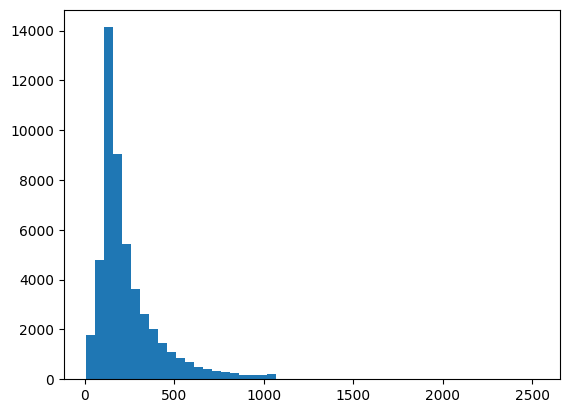

In [8]:
import matplotlib.pyplot as plt

# 훈련 및 테스트 시퀀스의 길이 계산
sequence_lengths = [len(s) for s in train_sequences] + [len(s) for s in test_sequences]

# 히스토그램으로 시퀀스 길이 분포 시각화
plt.hist(sequence_lengths, bins=50);

In [9]:
from tensorflow.keras.preprocessing.sequence import pad_sequences

# 최대 sequence 길이 설정
max_length = 150

# train sequence 패딩
train_padded = pad_sequences(train_sequences, maxlen=max_length, truncating='post', padding='post')

# test sequence 패딩
test_padded = pad_sequences(test_sequences, maxlen=max_length, truncating='post', padding='post')

# 패딩된 시sequence shape,  첫 번째 sequence 출력
print(train_padded.shape)
print(test_padded.shape)
print(train_padded[0])
print(test_padded[0])

(25000, 150)
(25000, 150)
[  59   12   14   35  439  400   18  174   29    1    9   33 1378 3401
   42  496    1  197   25   88  156   19   12  211  340   29   70  248
  213    9  486   62   70   88  116   99   24 5740   12 3317  657  777
   12   18    7   35  406 8228  178 2477  426    2   92 1253  140   72
  149   55    2    1 7525   72  229   70 2962   16    1 2880    1    1
 1506 4998    3   40 3947  119 1608   17 3401   14  163   19    4 1253
  927 7986    9    4   18   13   14 4200    5  102  148 1237   11  240
  692   13   44   25  101   39   12 7232    1   39 1378    1   52  409
   11   99 1214  874  145   10    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0    0    0    0    0
    0    0    0    0    0    0    0    0    0    0]
[  59   44   25  109   13   97 4115   16  742 4370   10   14  316    5
    2  593  354   16 1864 1212    1   16  680 7499 5595    1  773    6
   13 1037    1    1  439  491    1    4    1  334 3610   20  229    3

- sequence data 를 sentence 로 reverse conversion

In [10]:
# 시퀀스를 텍스트로 디코딩하는 함수 정의
def decode_review(sequence):
    return ' '.join([tokenizer.index_word.get(i, '<pad>') for i in sequence])

# 첫 번째 훈련 시퀀스 디코딩 및 출력
print(decode_review(train_padded[0]))
print()

# 원래 첫 번째 훈련 문장 출력
print(train_sentences[0])

b this was an absolutely terrible movie don't be <OOV> in by christopher walken or michael <OOV> both are great actors but this must simply be their worst role in history even their great acting could not redeem this movie's ridiculous storyline this movie is an early nineties us propaganda piece the most pathetic scenes were those when the <OOV> rebels were making their cases for <OOV> maria <OOV> <OOV> appeared phony and her pseudo love affair with walken was nothing but a pathetic emotional plug in a movie that was devoid of any real meaning i am disappointed that there are movies like this ruining <OOV> like christopher <OOV> good name i could barely sit through it <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad> <pad>

b"This was an absolutely terrible movie. Don't be lured in by Christopher Walken or Michael Ironside. Both are great actors, but 

## model define

In [11]:
import tensorflow as tf
from tensorflow.keras.layers import Dense, LSTM, Embedding, Dropout, Bidirectional
from tensorflow.keras.models import Sequential

model = Sequential([
    Embedding(vocab_size+1, 64),               # 어휘 사전 크기 + 1과 임베딩 차원 설정
    Bidirectional(tf.keras.layers.LSTM(64)),  # 양방향 LSTM 레이어
    Dense(64, activation='relu'),                    # 완전 연결 레이어
    Dense(1, activation='sigmoid')                # 이진 분류를 위한 출력 레이어
])

model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, None, 64)          640064    
                                                                 
 bidirectional (Bidirection  (None, 128)               66048     
 al)                                                             
                                                                 
 dense (Dense)               (None, 64)                8256      
                                                                 
 dense_1 (Dense)             (None, 1)                 65        
                                                                 
Total params: 714433 (2.73 MB)
Trainable params: 714433 (2.73 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


In [12]:
%%time
num_epochs = 30
history = model.fit(train_padded, train_labels, epochs=num_epochs, batch_size=128,
                validation_data=(test_padded, test_labels), verbose=1)

Epoch 1/30
196/196 [==============================] - 31s 137ms/step - loss: 0.4684 - accuracy: 0.7610 - val_loss: 0.3828 - val_accuracy: 0.8317
Epoch 2/30
196/196 [==============================] - 15s 76ms/step - loss: 0.2731 - accuracy: 0.8906 - val_loss: 0.3967 - val_accuracy: 0.8382
Epoch 3/30
196/196 [==============================] - 12s 59ms/step - loss: 0.2126 - accuracy: 0.9196 - val_loss: 0.3983 - val_accuracy: 0.8226
Epoch 4/30
196/196 [==============================] - 8s 39ms/step - loss: 0.1705 - accuracy: 0.9387 - val_loss: 0.4116 - val_accuracy: 0.8187
Epoch 5/30
196/196 [==============================] - 7s 33ms/step - loss: 0.1351 - accuracy: 0.9517 - val_loss: 0.5522 - val_accuracy: 0.8192
Epoch 6/30
196/196 [==============================] - 6s 28ms/step - loss: 0.0926 - accuracy: 0.9664 - val_loss: 0.6041 - val_accuracy: 0.8043
Epoch 7/30
196/196 [==============================] - 5s 25ms/step - loss: 0.0658 - accuracy: 0.9779 - val_loss: 0.6865 - val_accuracy: 0.

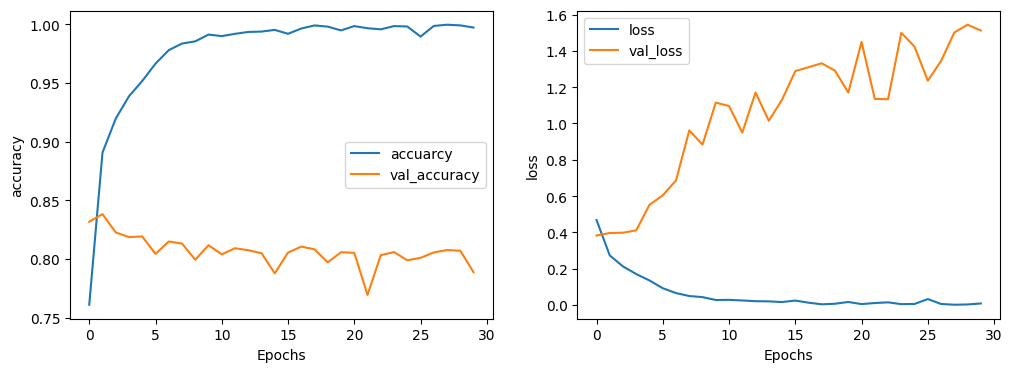

In [13]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(history.history['accuracy'])
ax1.plot(history.history['val_accuracy'])
ax1.set_xlabel('Epochs')
ax1.set_ylabel('accuracy')
ax1.legend(['accuarcy', 'val_accuracy'])

ax2.plot(history.history['loss'])
ax2.plot(history.history['val_loss'])
ax2.set_xlabel('Epochs')
ax2.set_ylabel('loss')
ax2.legend(['loss', 'val_loss'])
plt.show()

In [22]:
# 샘플 텍스트 정의
sample_texts =['The movei was terrible. I would not recommend the movie',
                         'The movei was fantastic. I would recommend the movie',
                         'The animation and graphics were out of this world']

for sample_text in sample_texts:
    # 샘플 텍스트를 시퀀스로 변환
    sample_seq = tokenizer.texts_to_sequences([sample_text])
    # 시퀀스에 패딩 적용 (지정된 최대 길이에 맞추어 패딩)
    sample_padded = pad_sequences(sample_seq, maxlen=max_length, padding='post', truncating='post')
    prediction = model.predict([sample_padded], verbose=0)
    if prediction > 0.5:
        print("긍정")
    else:
        print("부정")

부정
긍정
긍정
